In [2]:
import numpy as np
import healpy as hp
from astropy.io import fits
from astropy.table import Table
from astropy import units as u
from astropy.coordinates import SkyCoord
import pandas as pd

import astropy.coordinates as ac
#from mpl_toolkits.basemap import Basemap


from gala.coordinates import MagellanicStreamNidever08
import matplotlib.pyplot as plt
import os

#%matplotlib inline

In [3]:
# set up the plotting
# set font size
plt.rcParams.update({'font.size': 18})
# set the figure size
plt.rcParams.update({'figure.figsize': (10, 7)})
# set the font to latex
plt.rcParams.update({'text.usetex': True})

# Source - https://stackoverflow.com/a
# Posted by Sina Mansour L.
# Retrieved 2026-01-20, License - CC BY-SA 4.0

plt.rcParams.update({
"text.usetex": True,
"font.family": "sans-serif",
"font.sans-serif": ["Helvetica"]})


# Compare angular momentum distributions for stars

In [4]:
plots_dir = '/Users/mncavieres/Documents/2024-1/Delve/Plots/angular_momentum'

In [5]:
xshooter_merged = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Data/xshooter_nested_distance_merged.fits')
nested_results = Table.read("/Users/mncavieres/Documents/2024-1/Delve/Data/xshooter_ested_ALICE/fit_results.fits")

from astropy.table import join
# add to xshooter merger the columns from nested results that match on 'source_id' and are not already present
for col in nested_results.colnames:
    if col not in xshooter_merged.colnames and col != 'source_id':
        # join on source_id
        xshooter_merged = join(xshooter_merged, nested_results[['source_id', col]], keys='source_id', join_type='left')


Now the xshooter_merged table has the spectroscopic distances from MIST models fitting and the radial velocity measurements from xshooter, proper motions and sky positions from gaia. So everything needed to get the full 6D phase space position and velocity

In [6]:
def compute_angular_momentum(x,y,z, vx,vy,vz):
    Lx = y*vz - z*vy
    Ly = z*vx - x*vz
    Lz = x*vy - y*vx
    return Lx, Ly, Lz

In [7]:
# get xzy and vxvyvz for xshooter_merged
coords = SkyCoord(ra=xshooter_merged['ra']*u.degree, dec=xshooter_merged['dec']*u.degree,
                  distance=xshooter_merged['dist_pc_p50']*u.pc,
                  pm_ra_cosdec=xshooter_merged['pmra']*u.mas/u.yr, 
                  pm_dec=xshooter_merged['pmdec']*u.mas/u.yr,
                  radial_velocity=xshooter_merged['hel_vel']*u.km/u.s)
xshooter_merged['x'] = coords.galactocentric.x.to(u.kpc)
xshooter_merged['y'] = coords.galactocentric.y.to(u.kpc)
xshooter_merged['z'] = coords.galactocentric.z.to(u.kpc)
xshooter_merged['vx'] = coords.galactocentric.v_x.to(u.km/u.s)
xshooter_merged['vy'] = coords.galactocentric.v_y.to(u.km/u.s)
xshooter_merged['vz'] = coords.galactocentric.v_z.to(u.km/u.s)

lx, ly, lz = compute_angular_momentum(xshooter_merged['x'], xshooter_merged['y'], xshooter_merged['z'],
                                      xshooter_merged['vx'], xshooter_merged['vy'], xshooter_merged['vz'])
xshooter_merged['Lx'] = lx
xshooter_merged['Ly'] = ly
xshooter_merged['Lz'] = lz

# Compute L for DESI sources

In [8]:
desi_stars = Table.read('/Users/mncavieres/Documents/2025-1/DESI_HVS/Data/DESI/distxDESI_processed.fits')


In [9]:
desi_coords = SkyCoord(ra=desi_stars['ra'], dec=desi_stars['dec'], distance=desi_stars['DIST'],
                       pm_ra_cosdec=desi_stars['pmra'], pm_dec=desi_stars['pmdec'], radial_velocity=desi_stars['VRAD_2'])
desi_stars['x'] = desi_coords.galactocentric.x.to(u.kpc)
desi_stars['y'] = desi_coords.galactocentric.y.to(u.kpc)
desi_stars['z'] = desi_coords.galactocentric.z.to(u.kpc)
desi_stars['vx'] = desi_coords.galactocentric.v_x.to(u.km/u.s)
desi_stars['vy'] = desi_coords.galactocentric.v_y.to(u.km/u.s)
desi_stars['vz'] = desi_coords.galactocentric.v_z.to(u.km/u.s)

desi_stars['lx'], desi_stars['ly'], desi_stars['lz'] = compute_angular_momentum(desi_stars['x'], desi_stars['y'], desi_stars['z'],
                                                                              desi_stars['vx'], desi_stars['vy'], desi_stars['vz'])

# Compute L for simulations

In [10]:

# transform from Galactocentric to Stream coordinates
from astropy.coordinates import Galactocentric, ICRS

def add_stream_coords(smc1_sim):
    
    # Step 1: Convert RA/Dec to a SkyCoord object
    coords = Galactocentric(
        x=smc1_sim["x"] * u.kpc,
        y=smc1_sim["y"] * u.kpc,
        z=smc1_sim["z"] * u.kpc,
        v_x=smc1_sim["v_x"] * (u.km/u.s),
        v_y=smc1_sim["v_y"] * (u.km/u.s),
        v_z=smc1_sim["v_z"] * (u.km/u.s),
    )
    # Step 2: Convert RA/Dec to Magellanic Stream Coordinates
    mag_stream_coords = coords.transform_to(MagellanicStreamNidever08())

    # Add the new coordinates to the table
    smc1_sim['L_stream'] = mag_stream_coords.L.degree
    smc1_sim['B_stream'] = mag_stream_coords.B.degree
    smc1_sim['pm_l'] = mag_stream_coords.pm_L_cosB
    smc1_sim['pm_b'] = mag_stream_coords.pm_B

    # also add heliocentric radial velocity and distance

    smc1_sim['radial_velocity'] = coords.radial_velocity

    icrs_coords = coords.transform_to(ICRS())

    smc1_sim['distance'] = icrs_coords.distance.kpc
    smc1_sim['ra'] = icrs_coords.ra.degree
    smc1_sim['dec'] = icrs_coords.dec.degree
    smc1_sim['pmra'] = icrs_coords.pm_ra_cosdec
    smc1_sim['pmdec'] = icrs_coords.pm_dec

    return smc1_sim

smc1_sim  = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Data/for_Camila/SMC/SMC_model1_stars.csv')
smc1_sim = add_stream_coords(smc1_sim)


# now same for the other sim
smc2_sim = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Data/for_Camila/SMC/SMC_model2_stars.csv')
smc2_sim = add_stream_coords(smc2_sim)

smc1_sim['Lx'], smc1_sim['Ly'], smc1_sim['Lz'] = compute_angular_momentum(smc1_sim['x'], smc1_sim['y'], smc1_sim['z'],
                                                                              smc1_sim['v_x'], smc1_sim['v_y'], smc1_sim['v_z'])
smc2_sim['Lx'], smc2_sim['Ly'], smc2_sim['Lz'] = compute_angular_momentum(smc2_sim['x'], smc2_sim['y'], smc2_sim['z'],
                                                                              smc2_sim['v_x'], smc2_sim['v_y'], smc2_sim['v_z'])

In [11]:
smc1_sim

x,y,z,v_x,v_y,v_z,L_stream,B_stream,pm_l,pm_b,radial_velocity,distance,ra,dec,pmra,pmdec,Lx,Ly,Lz
,,,,,,,,mas / yr,mas / yr,km / s,,,,mas / yr,mas / yr,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
-16.102049,-56.001308,4.0137062,-68.126022,-123.40456,231.17325,39.09330555582678,15.886775519677258,0.7376911895533157,-0.008602668056512013,152.9858452752967,56.70777199604365,134.6068183677849,-39.610124292740466,0.48439347820771084,0.5564398038531333,-12450.694727030728,3448.9251621065137,-1828.0800688933361
-14.10895,-54.542347,4.2394748,-152.7663,-169.79294,235.5603,39.16978587310898,14.012773212834661,0.8046494542937608,0.3395053964908479,219.74520095287966,55.031888233561105,136.5549404138618,-40.751332345266036,0.24393345103300257,0.838582810465839,-12128.178731676187,2675.8596155457603,-5936.6324436931
-16.314566,-53.798203,3.0643797,-28.811497,-129.65881,235.8533,38.318945911850015,16.555198070319655,0.7818396349712755,-0.17866634240727527,145.08095270958793,54.50347326073935,133.31796993596024,-39.73464211062953,0.651151910492263,0.4681837953021086,-12291.159886329742,3759.554862634389,565.3204488865688
-16.256392,-54.220741,1.6936511,-67.376869,-113.34292,238.01213,36.79922110108482,16.643188727582647,0.8476914343281388,-0.020754980917751967,134.9791150270001,54.8530395867269,131.95394972789316,-40.7568809534627,0.590407983148716,0.6086295675535816,-12713.230694453117,3755.105577738555,-1810.6768254952885
-17.459179,-54.863682,1.3750458,-111.25585,-135.38344,234.3028,36.60081064111502,17.80814627066725,0.8447505017490515,0.10240687826553964,168.29411574645113,55.669030828039915,130.6675303179331,-40.09798605704566,0.5086321983815634,0.6821904907655235,-12668.555880348047,3937.75263613327,-3740.2218624439392
-16.70619,-57.909035,2.8153262,-87.430374,-123.20185,229.24554,37.800947450074,16.401013368400125,0.7470706165664921,0.05284501135420097,153.1502074535327,58.608484765698,133.0383651140953,-40.208553619885656,0.4579097497206129,0.5926430312362329,-12928.53460326043,3583.674525294601,-3004.77507357759
-14.942929,-57.906273,1.8790007,-105.50451,-129.24405,224.52937,36.61193225667994,14.83734808145755,0.7691207400242255,0.15984796738828097,158.4830741713302,58.33622200958284,133.5762123929035,-42.10388431559331,0.3923417100378414,0.6805630521694226,-12758.809335317173,3156.883386181573,-4178.08829596878
-16.195007,-60.298828,2.3860595,-88.966026,-148.30949,227.06976,37.15735798241376,15.677940923918456,0.7218049831425362,0.06547518001072057,174.86008660281698,60.88281352507985,133.20610608952072,-41.1515448982537,0.4323608014149413,0.5816816743603525,-13338.165134686626,3465.1181211737735,-2962.673870901098


In [12]:
# clean nans from desi_stars in any angular momentum column
desi_stars = desi_stars[~np.isnan(desi_stars['lx']) & ~np.isnan(desi_stars['ly']) & ~np.isnan(desi_stars['lz'])]

# Comparison

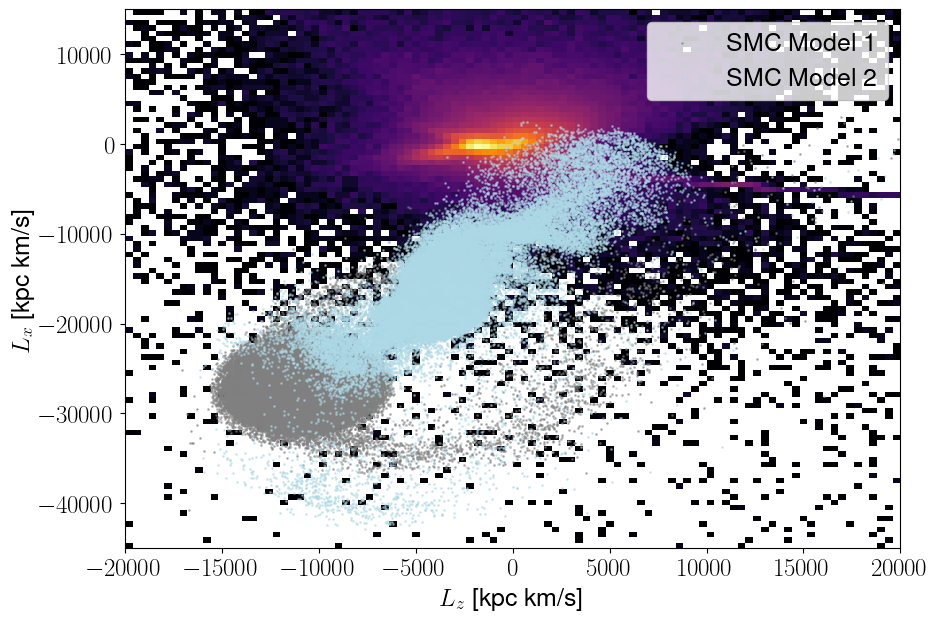

In [13]:
from matplotlib.colors import LogNorm
# 2d histogram of lz vs lx for desi stars
fig, ax = plt.subplots(figsize=(10,7))
ax.hist2d(desi_stars['lz'], desi_stars['lx'], bins=100, cmap='inferno',
          range=((-20000, 20000), (-45000, 15000)), norm=LogNorm())
# scatter plot of smc1_sim and smc2_sim on top
ax.scatter(smc1_sim['Lz'], smc1_sim['Lx'], s=1, color='gray', label='SMC Model 1', alpha=0.5)
ax.scatter(smc2_sim['Lz'], smc2_sim['Lx'], s=1, color='lightblue', label='SMC Model 2', alpha=0.5)

ax.set_xlabel(r'$L_z$ [kpc km/s]')
ax.set_ylabel(r'$L_x$ [kpc km/s]')

ax.legend()

plt.show()

In [14]:
# mask out the region of the simulation that is the main body of the LMC, we can do this in stream coordinates by masking the region around L_stream = 0, B_stream = 0, we can use a circular mask with a radius of 10 degrees
lmc_mask = (np.sqrt(smc1_sim['L_stream']**2 + smc1_sim['B_stream']**2) > 10)
smc1_sim_lmc_masked = smc1_sim[lmc_mask]

lmc_mask = (np.sqrt(smc2_sim['L_stream']**2 + smc2_sim['B_stream']**2) > 10)
smc2_sim_lmc_masked = smc2_sim[lmc_mask]

# mask out the region of the LMC and SMC by using the RA and Dec of the LMC and SMC, we can use a circular mask with a radius of 10 degrees around the center of the LMC and SMC
lmc_center = SkyCoord(ra=80.89416667*u.degree, dec=-69.75611111*u.degree, frame='icrs')
smc_center = SkyCoord(ra=13.18666667*u.degree, dec=-72.82861111*u.degree, frame='icrs')

lmc_mask = (smc1_sim['ra'] - lmc_center.ra.degree)**2 + (smc1_sim['dec'] - lmc_center.dec.degree)**2 > 10**2
smc1_sim_lmc_masked = smc1_sim[lmc_mask]   
lmc_mask = (smc2_sim['ra'] - lmc_center.ra.degree)**2 + (smc2_sim['dec'] - lmc_center.dec.degree)**2 > 10**2
smc2_sim_lmc_masked = smc2_sim[lmc_mask]

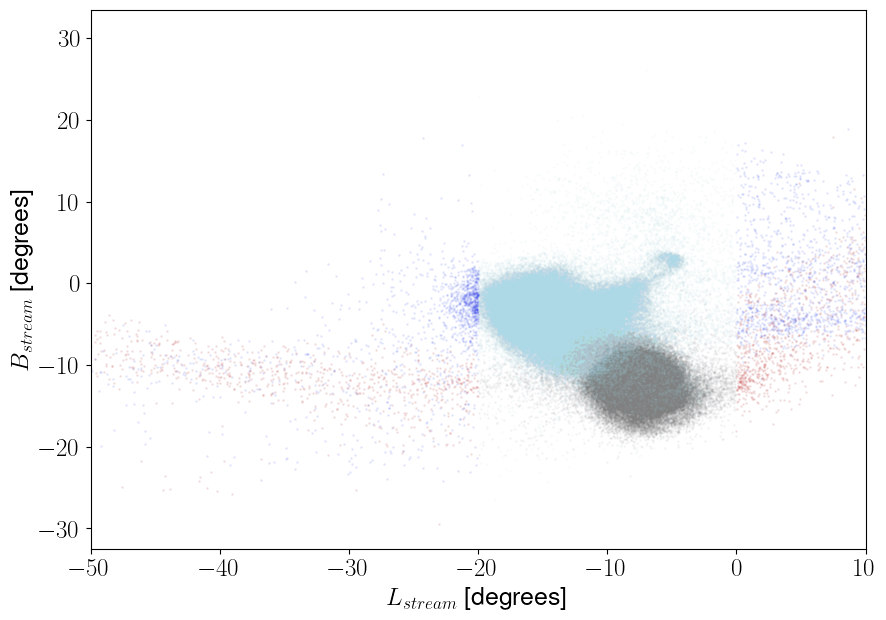

In [15]:
# show the L, B stream masking
fig, ax = plt.subplots(figsize=(10,7))
ax.scatter(smc1_sim['L_stream'], smc1_sim['B_stream'], s=1, color='gray', label='SMC Model 1', alpha=0.05)
ax.scatter(smc2_sim['L_stream'], smc2_sim['B_stream'], s=1, color='lightblue', label='SMC Model 2', alpha=0.05)

smc1_sim_lmc_masked = smc1_sim[(smc1_sim['L_stream'] >0) | (smc1_sim['L_stream'] < -20)]
smc2_sim_lmc_masked = smc2_sim[(smc2_sim['L_stream'] >0) | (smc2_sim['L_stream'] < -20)]
# now different color for the masked points
ax.scatter(smc1_sim_lmc_masked['L_stream'], smc1_sim_lmc_masked['B_stream'], s=1, color='red', label='SMC Model 1 Masked', alpha=0.05)
ax.scatter(smc2_sim_lmc_masked['L_stream'], smc2_sim_lmc_masked['B_stream'], s=1, color='blue', label='SMC Model 2 Masked', alpha=0.05)
ax.set_xlabel(r'$L_{stream}$ [degrees]')
ax.set_ylabel(r'$B_{stream}$ [degrees]')
ax.set_xlim(-50, 10)
plt.show()

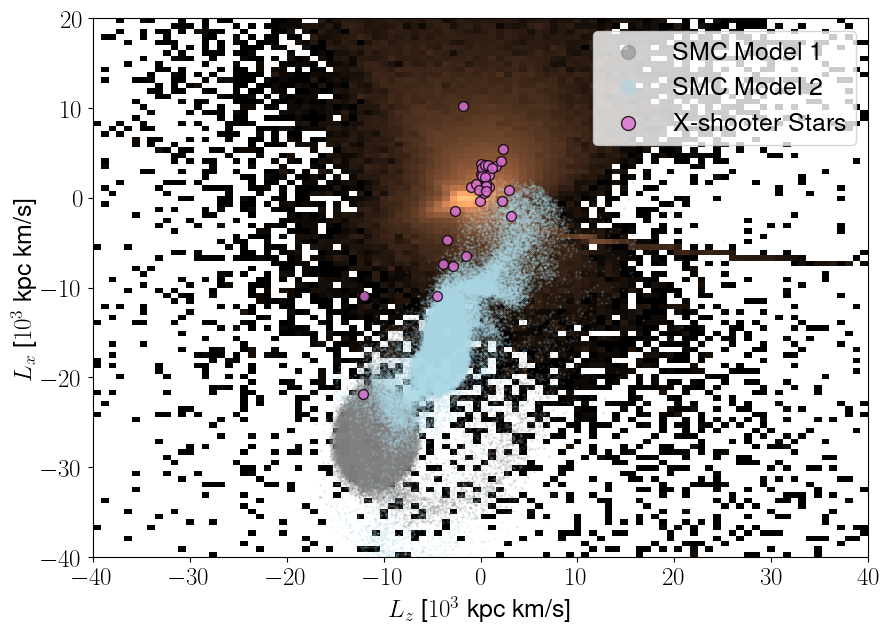

In [16]:
from matplotlib.colors import LogNorm
# 2d histogram of lz vs lx for desi stars
scale_factor = 1/1000
fig, ax = plt.subplots(figsize=(10,7))
ax.hist2d(desi_stars['lz']*scale_factor, desi_stars['lx']*scale_factor, bins=100, cmap='copper',
          range=((-40, 40), (-40, 20)), norm=LogNorm())
# scatter plot of smc1_sim and smc2_sim on top
#ax.scatter(smc1_sim_lmc_masked['Lz'], smc1_sim_lmc_masked['Lx'], s=1, color='gray', label='SMC Model 1', alpha=0.5)
#ax.scatter(smc2_sim_lmc_masked['Lz'], smc2_sim_lmc_masked['Lx'], s=1, color='lightblue', label='SMC Model 2', alpha=0.5)
ax.scatter(smc1_sim['Lz']*scale_factor, smc1_sim['Lx']*scale_factor, s=0.1, color='gray', label='SMC Model 1', alpha=0.5)
ax.scatter(smc2_sim['Lz']*scale_factor, smc2_sim['Lx']*scale_factor, s=0.1, color='lightblue', label='SMC Model 2', alpha=0.5)

# add xshooter stars on top
ax.scatter(xshooter_merged['Lz']*scale_factor, xshooter_merged['Lx']*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=0.8)
ax.set_xlabel(r'$L_z$ [$10^3$ kpc km/s]')
ax.set_ylabel(r'$L_x$ [$10^3$ kpc km/s]')

lgnd = ax.legend()
# set the legend marker size to 10
for handle in lgnd.legend_handles:
    handle.set_sizes([100])

plt.savefig(os.path.join(plots_dir, 'angular_momentum_lz_lx.png'), dpi=600)
plt.show()

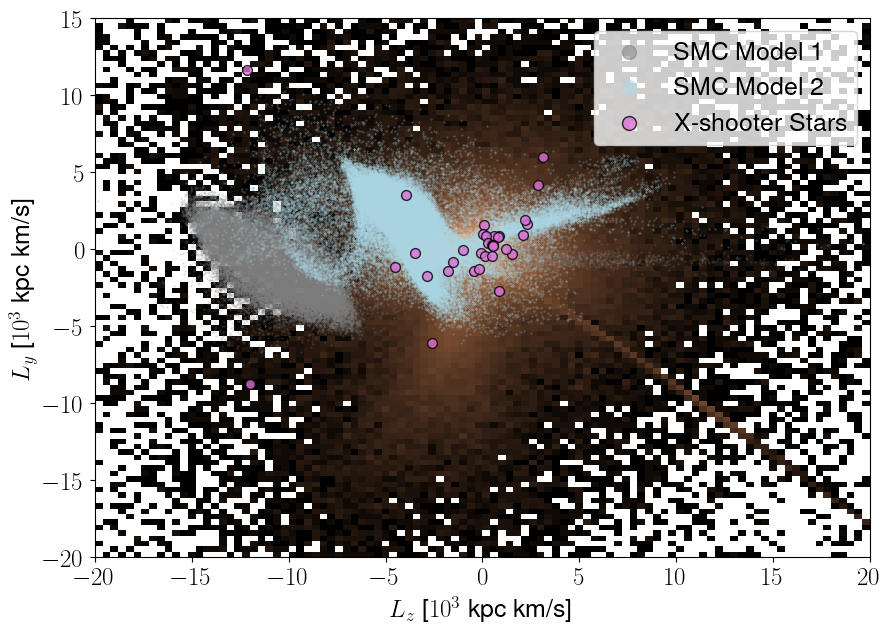

In [17]:
from matplotlib.colors import LogNorm
# 2d histogram of lz vs lx for desi stars
scale_factor = 1/1000
fig, ax = plt.subplots(figsize=(10,7))
ax.hist2d(desi_stars['lz']*scale_factor, desi_stars['ly']*scale_factor, bins=100, cmap='copper',
          range=((-20, 20), (-20, 15)), norm=LogNorm())
# scatter plot of smc1_sim and smc2_sim on top
#ax.scatter(smc1_sim_lmc_masked['Lz'], smc1_sim_lmc_masked['Lx'], s=1, color='gray', label='SMC Model 1', alpha=0.5)
#ax.scatter(smc2_sim_lmc_masked['Lz'], smc2_sim_lmc_masked['Lx'], s=1, color='lightblue', label='SMC Model 2', alpha=0.5)
ax.scatter(smc1_sim['Lz']*scale_factor, smc1_sim['Ly']*scale_factor, s=0.1, color='gray', label='SMC Model 1', alpha=0.5)
ax.scatter(smc2_sim['Lz']*scale_factor, smc2_sim['Ly']*scale_factor, s=0.1, color='lightblue', label='SMC Model 2', alpha=0.5)

# add xshooter stars on top
ax.scatter(xshooter_merged['Lz']*scale_factor, xshooter_merged['Ly']*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=0.8)
ax.set_xlabel(r'$L_z$ [$10^3$ kpc km/s]')
ax.set_ylabel(r'$L_y$ [$10^3$ kpc km/s]')

lgnd = ax.legend()
# set the legend marker size to 10
for handle in lgnd.legend_handles:
    handle.set_sizes([100])
plt.savefig(os.path.join(plots_dir, 'angular_momentum_lz_ly.png'), dpi=600)
plt.show()

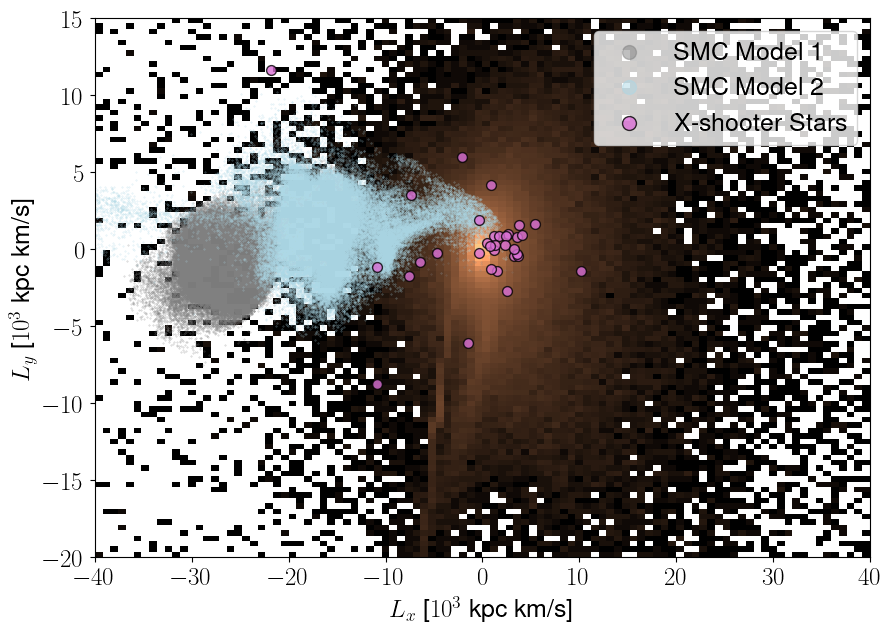

In [18]:
from matplotlib.colors import LogNorm
# 2d histogram of lz vs lx for desi stars
scale_factor = 1/1000
fig, ax = plt.subplots(figsize=(10,7))
ax.hist2d(desi_stars['lx']*scale_factor, desi_stars['ly']*scale_factor, bins=100, cmap='copper',
          range=((-40, 40), (-20, 15)), norm=LogNorm())
# scatter plot of smc1_sim and smc2_sim on top
#ax.scatter(smc1_sim_lmc_masked['Lz'], smc1_sim_lmc_masked['Lx'], s=1, color='gray', label='SMC Model 1', alpha=0.5)
#ax.scatter(smc2_sim_lmc_masked['Lz'], smc2_sim_lmc_masked['Lx'], s=1, color='lightblue', label='SMC Model 2', alpha=0.5)
ax.scatter(smc1_sim['Lx']*scale_factor, smc1_sim['Ly']*scale_factor, s=0.1, color='gray', label='SMC Model 1', alpha=0.5)
ax.scatter(smc2_sim['Lx']*scale_factor, smc2_sim['Ly']*scale_factor, s=0.1, color='lightblue', label='SMC Model 2', alpha=0.5)

# add xshooter stars on top
ax.scatter(xshooter_merged['Lx']*scale_factor, xshooter_merged['Ly']*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=0.8)
ax.set_xlabel(r'$L_x$ [$10^3$ kpc km/s]')
ax.set_ylabel(r'$L_y$ [$10^3$ kpc km/s]')

lgnd = ax.legend()
# set the legend marker size to 10
for handle in lgnd.legend_handles:
    handle.set_sizes([100])
plt.savefig(os.path.join(plots_dir, 'angular_momentum_lx_ly.png'), dpi=600)
plt.show()

# Apply Chandra 2023 selections

- LX < 8.5 × 103 kpc km s−1

- LMS < −15 deg

- LY ≲
1 × 103 kpc km s−1

In [19]:
# apply the same masking
# Lx < 8.5e3 and Ly < 1e3 and LMS < -15
lx_threshold = -8500
ly_threshold = 1000
lz_threshold = 5000
lms_threshold = -15
mask_stream_l_sim1 = ((smc1_sim['Lx'] < lx_threshold) & (smc1_sim['Ly'] < ly_threshold) & (smc1_sim['L_stream'] < lms_threshold) & (smc1_sim['Lz'] < lz_threshold)
)
mask_stream_l_sim2 = ((smc2_sim['Lx'] < lx_threshold) & (smc2_sim['Ly'] < ly_threshold) & (smc2_sim['L_stream'] < lms_threshold) & (smc2_sim['Lz'] < lz_threshold)
                      )
mask_stream_l_xshooter = ((xshooter_merged['Lx'] < lx_threshold) & (xshooter_merged['Ly'] < ly_threshold) & (xshooter_merged['L_stream'] < lms_threshold) & (xshooter_merged['Lz'] < lz_threshold)
                        )
mask_stream_l_desi = ((desi_stars['lx'] < lx_threshold) & (desi_stars['ly'] < ly_threshold) & (desi_stars['lz'] < lms_threshold) & (desi_stars['lz'] < lz_threshold)
                        )


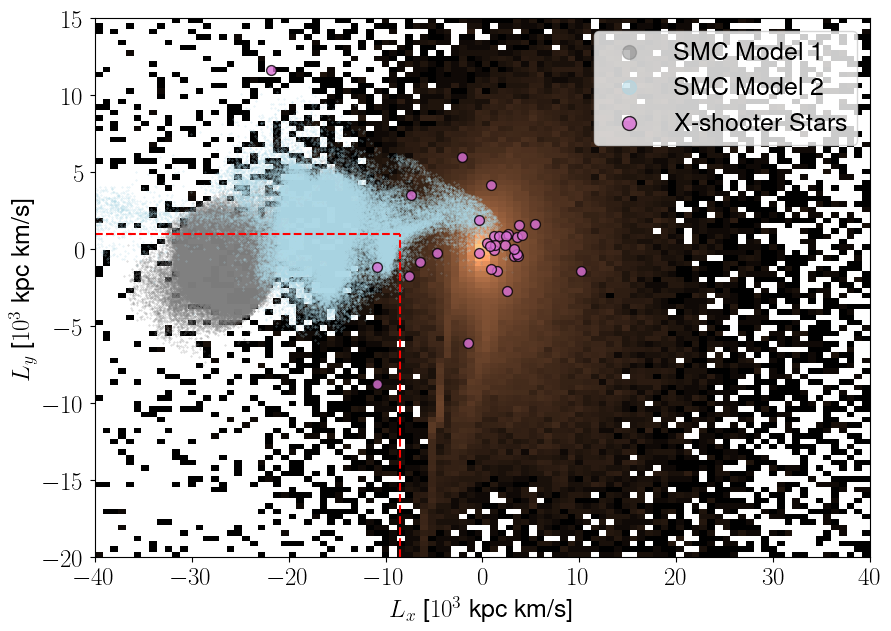

In [20]:
scale_factor = 1/1000
fig, ax = plt.subplots(figsize=(10,7))
ax.hist2d(desi_stars['lx']*scale_factor, desi_stars['ly']*scale_factor, bins=100, cmap='copper',
          range=((-40, 40), (-20, 15)), norm=LogNorm())
# scatter plot of smc1_sim and smc2_sim on top
#ax.scatter(smc1_sim_lmc_masked['Lz'], smc1_sim_lmc_masked['Lx'], s=1, color='gray', label='SMC Model 1', alpha=0.5)
# #ax.scatter(smc2_sim_lmc_masked['Lz'], smc2_sim_lmc_masked['Lx'], s=1, color='lightblue', label='SMC Model 2', alpha=0.5)
# ax.scatter(smc1_sim['Lx'][mask_stream_l_sim1]*scale_factor, smc1_sim['Ly'][mask_stream_l_sim1]*scale_factor, s=0.1, color='gray', label='SMC Model 1', alpha=0.5)
# ax.scatter(smc2_sim['Lx'][mask_stream_l_sim2]*scale_factor, smc2_sim['Ly'][mask_stream_l_sim2]*scale_factor, s=0.1, color='lightblue', label='SMC Model 2', alpha=0.5)
ax.scatter(smc1_sim['Lx']*scale_factor, smc1_sim['Ly']*scale_factor, s=0.1, color='gray', label='SMC Model 1', alpha=0.5)
ax.scatter(smc2_sim['Lx']*scale_factor, smc2_sim['Ly']*scale_factor, s=0.1, color='lightblue', label='SMC Model 2', alpha=0.5)


# xshooter 
#ax.scatter(xshooter_merged['Lx'][mask_stream_l_xshooter]*scale_factor, xshooter_merged['Ly'][mask_stream_l_xshooter]*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=0.8)
# all xshooter
ax.scatter(xshooter_merged['Lx']*scale_factor, xshooter_merged['Ly']*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=0.8)

# bounding box
ax.vlines(lx_threshold*scale_factor, -20, 1, color='red', linestyle='--')
ax.hlines(ly_threshold*scale_factor, -40, lx_threshold*scale_factor, color='red', linestyle='--')
ax.set_xlabel(r'$L_x$ [$10^3$ kpc km/s]')
ax.set_ylabel(r'$L_y$ [$10^3$ kpc km/s]')

lgnd = ax.legend()
# set the legend marker size to 10
for handle in lgnd.legend_handles:
    handle.set_sizes([100])
plt.savefig(os.path.join(plots_dir, 'angular_momentum_lx_ly_stream_masked.png'), dpi=600)
plt.show()


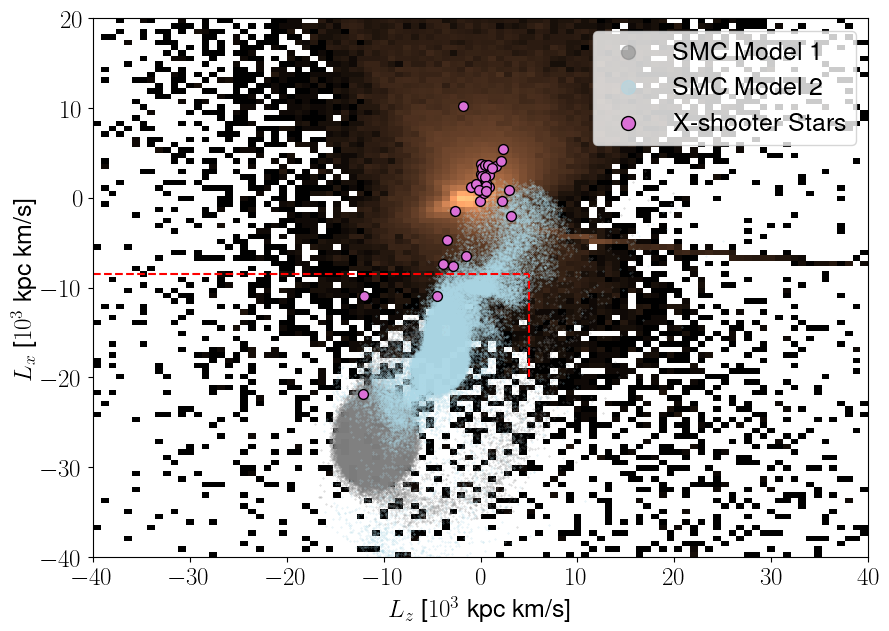

In [21]:
# lz vs lx with the stream masking

fig, ax = plt.subplots(figsize=(10,7))
ax.hist2d(desi_stars['lz']*scale_factor, desi_stars['lx']*scale_factor, bins=100, cmap='copper',
          range=((-40, 40), (-40, 20)), norm=LogNorm())
# scatter plot of smc1_sim and smc2_sim on top
ax.scatter(smc1_sim['Lz']*scale_factor, smc1_sim['Lx']*scale_factor, s=0.1, color='gray', label='SMC Model 1', alpha=0.5)
ax.scatter(smc2_sim['Lz']*scale_factor, smc2_sim['Lx']*scale_factor, s=0.1, color='lightblue', label='SMC Model 2', alpha=0.5)
# ax.scatter(smc1_sim['Lz'][mask_stream_l_sim1]*scale_factor, smc1_sim['Lx'][mask_stream_l_sim1]*scale_factor, s=0.1, color='gray', label='SMC Model 1', alpha=0.5)
# ax.scatter(smc2_sim['Lz'][mask_stream_l_sim2]*scale_factor, smc2_sim['Lx'][mask_stream_l_sim2]*scale_factor, s=0.1, color='lightblue', label='SMC Model 2', alpha=0.5)

# xshooter 
#ax.scatter(xshooter_merged['Lz'][mask_stream_l_xshooter]*scale_factor, xshooter_merged['Lx'][mask_stream_l_xshooter]*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=0.8)
ax.scatter(xshooter_merged['Lz']*scale_factor, xshooter_merged['Lx']*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=1)

# show box
ax.vlines(lz_threshold*scale_factor, -20, lx_threshold*scale_factor, color='red', linestyle='--')
ax.hlines(lx_threshold*scale_factor, -40, lz_threshold*scale_factor, color='red', linestyle='--')

ax.set_xlabel(r'$L_z$ [$10^3$ kpc km/s]')
ax.set_ylabel(r'$L_x$ [$10^3$ kpc km/s]')

lgnd = ax.legend(loc='upper right')
# set the legend marker size to 10
for handle in lgnd.legend_handles:
    handle.set_sizes([100])
plt.savefig(os.path.join(plots_dir, 'angular_momentum_lz_lx_stream_masked.png'), dpi=600)
plt.show()


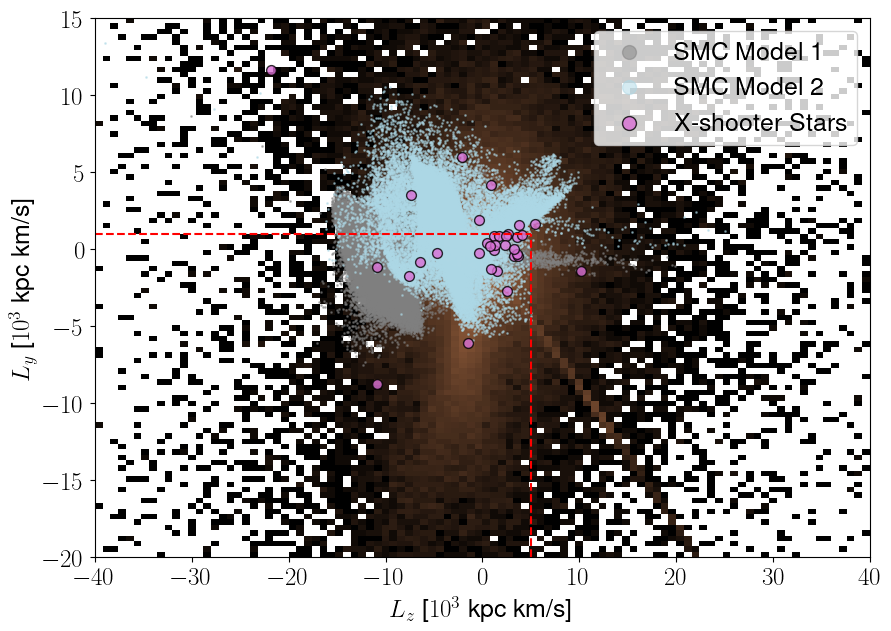

In [22]:
# lz vs ly with the same masking

fig, ax = plt.subplots(figsize=(10,7))
ax.hist2d(desi_stars['lz']*scale_factor, desi_stars['ly']*scale_factor, bins=100, cmap='copper',
          range=((-40, 40), (-20, 15)), norm=LogNorm())
# scatter plot of smc1_sim and smc2_sim on top
ax.scatter(smc1_sim['Lz']*scale_factor, smc1_sim['Ly']*scale_factor, s=1, color='gray', label='SMC Model 1', alpha=0.5)
ax.scatter(smc2_sim['Lz']*scale_factor, smc2_sim['Ly']*scale_factor, s=1, color='lightblue', label='SMC Model 2', alpha=0.5)
#ax.scatter(smc1_sim['Lz'][mask_stream_l_sim1]*scale_factor, smc1_sim['Ly'][mask_stream_l_sim1]*scale_factor, s=0.1, color='gray', label='SMC Model 1', alpha=0.5)
#ax.scatter(smc2_sim['Lz'][mask_stream_l_sim2]*scale_factor, smc2_sim['Ly'][mask_stream_l_sim2]*scale_factor, s=0.1, color='lightblue', label='SMC Model 2', alpha=0.5)

# xshooter 
#ax.scatter(xshooter_merged['Lz'][mask_stream_l_xshooter]*scale_factor, xshooter_merged['Ly'][mask_stream_l_xshooter]*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=0.8)
ax.scatter(xshooter_merged['Lx']*scale_factor, xshooter_merged['Ly']*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=0.8)

# show box
ax.vlines(lz_threshold*scale_factor, -20, ly_threshold*scale_factor, color='red', linestyle='--')
ax.hlines(ly_threshold*scale_factor, -40, lz_threshold*scale_factor, color='red', linestyle='--')

ax.set_xlabel(r'$L_z$ [$10^3$ kpc km/s]')
ax.set_ylabel(r'$L_y$ [$10^3$ kpc km/s]')

lgnd = ax.legend(loc='upper right')
# set the legend marker size to 10
for handle in lgnd.legend_handles:
    handle.set_sizes([100])
plt.savefig(os.path.join(plots_dir, 'angular_momentum_lz_ly_stream_masked.png'), dpi=600)
plt.show()


# With Chandra + Zaritzky targets

In [23]:
chandra = Table.read('/Users/mncavieres/Documents/2024-1/Delve/Data/ChandraMS_xGaia.csv')

In [24]:
chandra

Gaia_eDR3_sourceid,RA,DEC,gmag,vgsr,feh,feh_error,alphafe,alphafe_error,Distance,Distance_error,fbound_LMC,DR3Name,RAdeg,DEdeg,errHalfMaj,errHalfMin,errPosAng,SolID,Source,RandomI,e_RAdeg,e_DEdeg,Plx,e_Plx,RPlx,PM,pmRA,e_pmRA,pmDE,e_pmDE,RADEcor,RAPlxcor,RApmRAcor,RApmDEcor,DEPlxcor,DEpmRAcor,DEpmDEcor,PlxpmRAcor,PlxpmDEcor,pmRApmDEcor,NAL,NAC,NgAL,NbAL,gofAL,chi2AL,epsi,sepsi,Solved,APF,nueff,pscol,e_pscol,RApscolCorr,DEpscolCorr,PlxpscolCorr,pmRApscolCorr,pmDEpscolCorr,MatchObsA,Nper,amax,MatchObs,IPDgofha,IPDgofhp,IPDfmp,IPDfow,RUWE,Dup,o_Gmag,FG,e_FG,RFG,Gmag,e_Gmag,o_BPmag,FBP,e_FBP,RFBP,BPmag,e_BPmag,o_RPmag,FRP,e_FRP,RFRP,RPmag,e_RPmag,E(BP/RP),NBPcont,NBPblend,NRPcont,NRPblend,Mode,BP-RP,BP-G,G-RP,RV,e_RV,n_RV,o_RV,o_RVd,RVNper,RVS/N,RVgof,RVchi2,RVTdur,RVamp,RVtempTeff,RVtemplogg,RVtemp[Fe/H],Vatmparam,vbroad,e_Vbroad,o_Vbroad,GRVSmag,e_GRVSmag,o_GRVSmag,RVSS/N,VarFlag,PQSO,PGal,PSS,Teff,b_Teff_x,B_Teff_xa,logg,b_logg_x,B_logg_xa,[Fe/H],b_[Fe/H]_x,B_[Fe/H]_xa,Dist,b_Dist_x,B_Dist_xa,A0,b_A0_x,B_A0_xa,AG,b_AG_x,B_AG_xa,E(BP-RP),b_E(BP-RP)_x,B_E(BP-RP)_xa,Lib,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,RADEcorJ2000,angDist
int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,str28,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,float64,float64,float64,float64,int64,str5,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,int64,float64,float64,int64,int64,float64,int64,int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64,float64,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str13,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str7,float64,float64,float64,float64,float64,float64
6611869850296545024,333.05859,-33.8833,17.1,-110.3,-2.45,0.05,0.25,0.09,64,5,0.11,Gaia DR3 6611869850296545024,333.05859314712,-33.88330216643,0.0,0.0,73.0,1636148068921376768,6611869850296545024,207486085,0.0634,0.0514,-0.0978,0.0722,-1.3546,1.453,0.309,0.087,-1.419,0.063,0.1392,0.1007,-0.41,0.2104,-0.0009,0.2643,-0.5623,-0.2432,-0.0011,0.0152,570,0,566,4,2.0591,659.5,0.179,1.3618,31,false,1.458,--,--,--,--,--,--,--,65,20,0.124725,66,0.01832,158.4,0,0,1.061,0,543,2614.96893,1.60592,1628.33,17.1437,0.002835,61,1141.05,8.41304,135.628,17.695284,0.008478,59,2127.53,7.77321,273.701,16.428204,0.005479,1.25,0,1,0,1,0,1.26708,0.551584,0.715496,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,NOT_AVAILABLE,0.0,0.0,0.999996,5013.2,4801.0,5384.3,4.2988,4.2537,4.3315,-1.3506,-1.7692,-0.7888,1876.5206,1654.3492,2457.332,0.5801,0.375,0.8624,0.4592,0.2945,0.6898,0.2493,0.1598,0.3734,PHOENIX,333.05859149262,-33.88329585804,1.412833,1.035745,-0.0072,0.012218
6619464348908375808,329.91349,-27.49912,17.6,-74.7,-2.25,0.04,0.4,0.06,80,6,0.01,Gaia DR3 6619464348908375808,329.91349341227,-27.49911670461,0.0,0.0,52.0,1636148068921376768,6619464348908375808,597522692,0.0737,0.0638,-0.0081,0.1205,-0.0676,1.149,0.023,0.112,-1.149,0.082,0.5478,0.0241,-0.1694,-0.1536,-0.0351,-0.0275,-0.56,-0.5549,-0.0716,0.3442,640,0,639,1,-1.2784,614.63,0.0,0.0,31,false,1.454,--,--,--,--,--,--,--,73,17,0.170874,81,0.006102,162.5,0,0,0.964,0,674,1731.33252,1.15709,1496.29,17.591415,0.002849,75,738.408,7.36566,100.25,18.1678,0.011184,71,1406.14,7.83052,179.571,16.877827,0.00713,1.239,0,1,0,0,0,1.289974,0.576385,0.713589,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,NOT_AVAILABLE,0.0,0.0,0.999996,4767.3,4714.3,5185.3,4.8458,4.6491,4.8808,-1.7044,-1.8285,-0.

In [28]:
chandra_coords = SkyCoord(ra=chandra['RA']*u.degree, dec=chandra['DEC']*u.degree,
                            distance=chandra['Distance']*u.kpc,
                            pm_ra_cosdec=chandra['pmRA']*u.mas/u.yr,
                            pm_dec=chandra['pmDE']*u.mas/u.yr,
                            radial_velocity=chandra['vgsr']*u.km/u.s)

chandra['x'] = chandra_coords.galactocentric.x.to(u.kpc)
chandra['y'] = chandra_coords.galactocentric.y.to(u.kpc)
chandra['z'] = chandra_coords.galactocentric.z.to(u.kpc)
chandra['vx'] = chandra_coords.galactocentric.v_x.to(u.km/u.s)
chandra['vy'] = chandra_coords.galactocentric.v_y.to(u.km/u.s)
chandra['vz'] = chandra_coords.galactocentric.v_z.to(u.km/u.s)
chandra['Lx'], chandra['Ly'], chandra['Lz'] = compute_angular_momentum(chandra['x'], chandra['y'], chandra['z'],
                                                                          chandra['vx'], chandra['vy'], chandra['vz'])

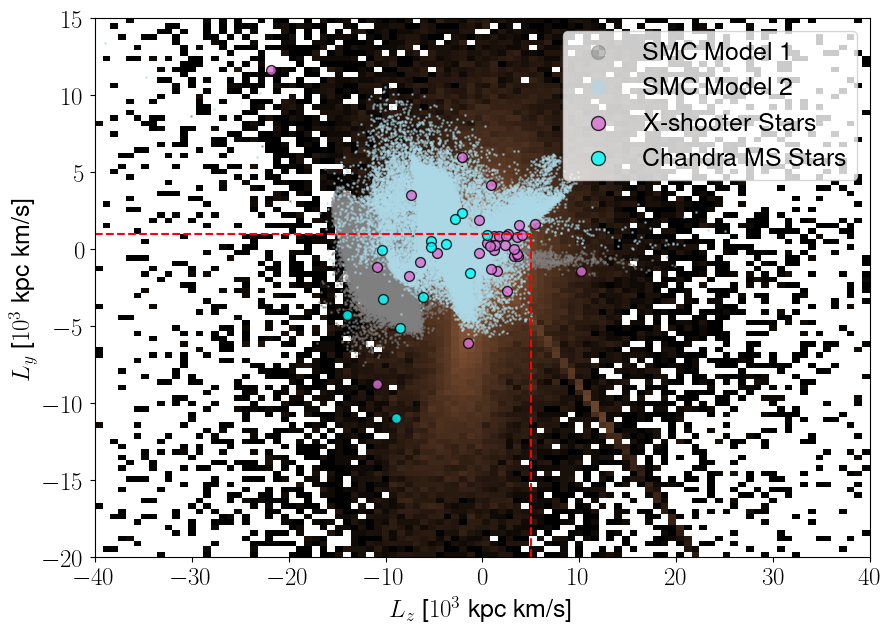

In [30]:
# lz vs ly with the same masking

fig, ax = plt.subplots(figsize=(10,7))
ax.hist2d(desi_stars['lz']*scale_factor, desi_stars['ly']*scale_factor, bins=100, cmap='copper',
          range=((-40, 40), (-20, 15)), norm=LogNorm())
# scatter plot of smc1_sim and smc2_sim on top
ax.scatter(smc1_sim['Lz']*scale_factor, smc1_sim['Ly']*scale_factor, s=1, color='gray', label='SMC Model 1', alpha=0.5)
ax.scatter(smc2_sim['Lz']*scale_factor, smc2_sim['Ly']*scale_factor, s=1, color='lightblue', label='SMC Model 2', alpha=0.5)
#ax.scatter(smc1_sim['Lz'][mask_stream_l_sim1]*scale_factor, smc1_sim['Ly'][mask_stream_l_sim1]*scale_factor, s=0.1, color='gray', label='SMC Model 1', alpha=0.5)
#ax.scatter(smc2_sim['Lz'][mask_stream_l_sim2]*scale_factor, smc2_sim['Ly'][mask_stream_l_sim2]*scale_factor, s=0.1, color='lightblue', label='SMC Model 2', alpha=0.5)

# xshooter 
#ax.scatter(xshooter_merged['Lz'][mask_stream_l_xshooter]*scale_factor, xshooter_merged['Ly'][mask_stream_l_xshooter]*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=0.8)
ax.scatter(xshooter_merged['Lx']*scale_factor, xshooter_merged['Ly']*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=0.8)

# add chandra stars on top
ax.scatter(chandra['Lz']*scale_factor, chandra['Ly']*scale_factor, s=50, color='cyan', label='Chandra MS Stars', edgecolor='black', alpha=0.8)

# show box
ax.vlines(lz_threshold*scale_factor, -20, ly_threshold*scale_factor, color='red', linestyle='--')
ax.hlines(ly_threshold*scale_factor, -40, lz_threshold*scale_factor, color='red', linestyle='--')

ax.set_xlabel(r'$L_z$ [$10^3$ kpc km/s]')
ax.set_ylabel(r'$L_y$ [$10^3$ kpc km/s]')

lgnd = ax.legend(loc='upper right')
# set the legend marker size to 10
for handle in lgnd.legend_handles:
    handle.set_sizes([100])
#plt.savefig(os.path.join(plots_dir, 'angular_momentum_lz_ly_stream_masked.png'), dpi=600)
plt.show()


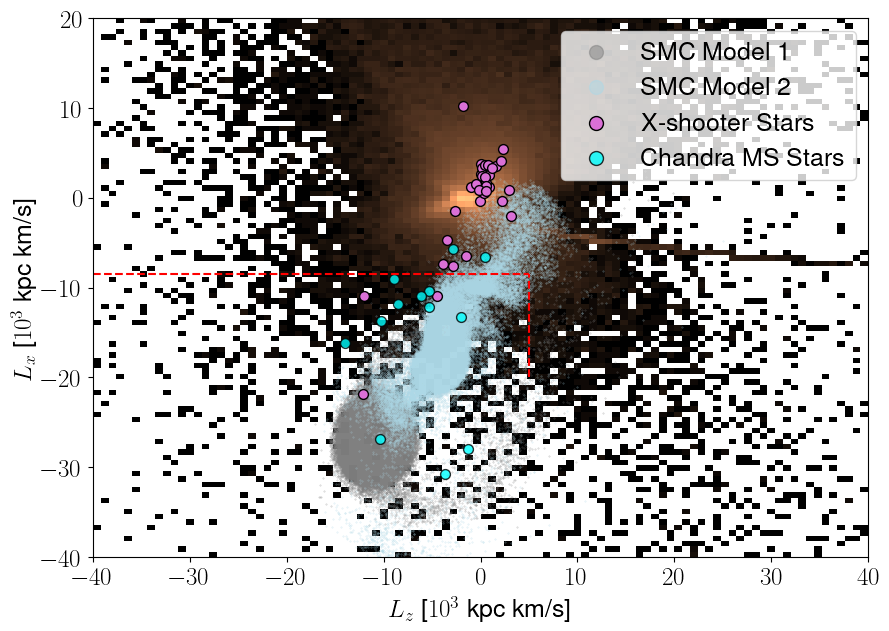

In [31]:
# lz vs lx with the stream masking

fig, ax = plt.subplots(figsize=(10,7))
ax.hist2d(desi_stars['lz']*scale_factor, desi_stars['lx']*scale_factor, bins=100, cmap='copper',
          range=((-40, 40), (-40, 20)), norm=LogNorm())
# scatter plot of smc1_sim and smc2_sim on top
ax.scatter(smc1_sim['Lz']*scale_factor, smc1_sim['Lx']*scale_factor, s=0.1, color='gray', label='SMC Model 1', alpha=0.5)
ax.scatter(smc2_sim['Lz']*scale_factor, smc2_sim['Lx']*scale_factor, s=0.1, color='lightblue', label='SMC Model 2', alpha=0.5)
# ax.scatter(smc1_sim['Lz'][mask_stream_l_sim1]*scale_factor, smc1_sim['Lx'][mask_stream_l_sim1]*scale_factor, s=0.1, color='gray', label='SMC Model 1', alpha=0.5)
# ax.scatter(smc2_sim['Lz'][mask_stream_l_sim2]*scale_factor, smc2_sim['Lx'][mask_stream_l_sim2]*scale_factor, s=0.1, color='lightblue', label='SMC Model 2', alpha=0.5)

# xshooter 
#ax.scatter(xshooter_merged['Lz'][mask_stream_l_xshooter]*scale_factor, xshooter_merged['Lx'][mask_stream_l_xshooter]*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=0.8)
ax.scatter(xshooter_merged['Lz']*scale_factor, xshooter_merged['Lx']*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=1)


# add chandra stars on top
ax.scatter(chandra['Lz']*scale_factor, chandra['Lx']*scale_factor, s=50, color='cyan', label='Chandra MS Stars', edgecolor='black', alpha=0.8)
# show box
ax.vlines(lz_threshold*scale_factor, -20, lx_threshold*scale_factor, color='red', linestyle='--')
ax.hlines(lx_threshold*scale_factor, -40, lz_threshold*scale_factor, color='red', linestyle='--')

ax.set_xlabel(r'$L_z$ [$10^3$ kpc km/s]')
ax.set_ylabel(r'$L_x$ [$10^3$ kpc km/s]')

lgnd = ax.legend(loc='upper right')
# set the legend marker size to 10
for handle in lgnd.legend_handles:
    handle.set_sizes([100])
plt.savefig(os.path.join(plots_dir, 'angular_momentum_lz_lx_chandra.png'), dpi=600)
plt.show()


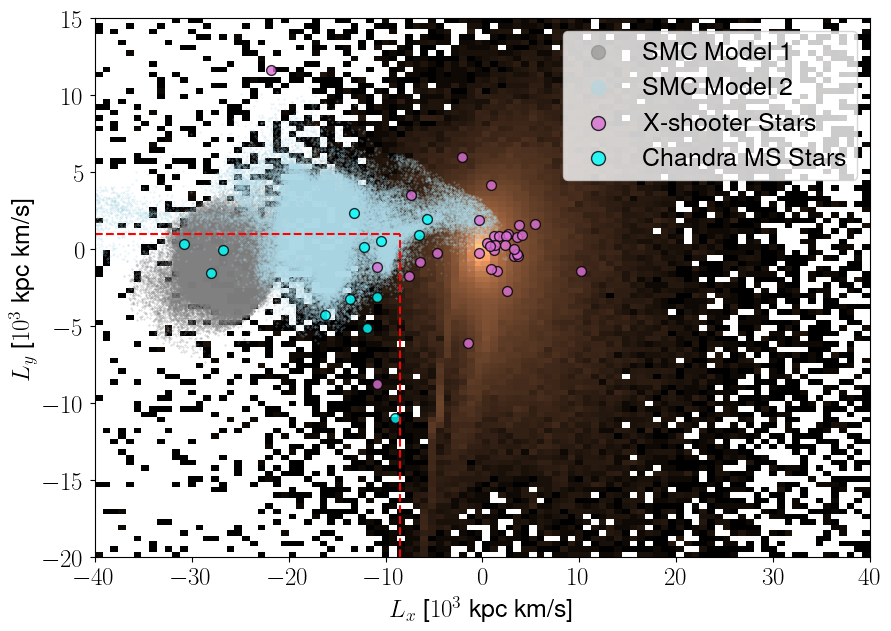

In [32]:
scale_factor = 1/1000
fig, ax = plt.subplots(figsize=(10,7))
ax.hist2d(desi_stars['lx']*scale_factor, desi_stars['ly']*scale_factor, bins=100, cmap='copper',
          range=((-40, 40), (-20, 15)), norm=LogNorm())
# scatter plot of smc1_sim and smc2_sim on top
#ax.scatter(smc1_sim_lmc_masked['Lz'], smc1_sim_lmc_masked['Lx'], s=1, color='gray', label='SMC Model 1', alpha=0.5)
# #ax.scatter(smc2_sim_lmc_masked['Lz'], smc2_sim_lmc_masked['Lx'], s=1, color='lightblue', label='SMC Model 2', alpha=0.5)
# ax.scatter(smc1_sim['Lx'][mask_stream_l_sim1]*scale_factor, smc1_sim['Ly'][mask_stream_l_sim1]*scale_factor, s=0.1, color='gray', label='SMC Model 1', alpha=0.5)
# ax.scatter(smc2_sim['Lx'][mask_stream_l_sim2]*scale_factor, smc2_sim['Ly'][mask_stream_l_sim2]*scale_factor, s=0.1, color='lightblue', label='SMC Model 2', alpha=0.5)
ax.scatter(smc1_sim['Lx']*scale_factor, smc1_sim['Ly']*scale_factor, s=0.1, color='gray', label='SMC Model 1', alpha=0.5)
ax.scatter(smc2_sim['Lx']*scale_factor, smc2_sim['Ly']*scale_factor, s=0.1, color='lightblue', label='SMC Model 2', alpha=0.5)


# xshooter 
#ax.scatter(xshooter_merged['Lx'][mask_stream_l_xshooter]*scale_factor, xshooter_merged['Ly'][mask_stream_l_xshooter]*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=0.8)
# all xshooter
ax.scatter(xshooter_merged['Lx']*scale_factor, xshooter_merged['Ly']*scale_factor, s=50, color='orchid', label='X-shooter Stars', edgecolor='black', alpha=0.8)

# add chandra stars on top
ax.scatter(chandra['Lx']*scale_factor, chandra['Ly']*scale_factor, s=50, color='cyan', label='Chandra MS Stars', edgecolor='black', alpha=0.8)

# bounding box
ax.vlines(lx_threshold*scale_factor, -20, 1, color='red', linestyle='--')
ax.hlines(ly_threshold*scale_factor, -40, lx_threshold*scale_factor, color='red', linestyle='--')
ax.set_xlabel(r'$L_x$ [$10^3$ kpc km/s]')
ax.set_ylabel(r'$L_y$ [$10^3$ kpc km/s]')

lgnd = ax.legend()
# set the legend marker size to 10
for handle in lgnd.legend_handles:
    handle.set_sizes([100])
plt.savefig(os.path.join(plots_dir, 'angular_momentum_lx_ly_chandra.png'), dpi=600)
plt.show()
